In [1]:
from Models import aggregate_model, IndividualModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_fit = pd.read_csv("best_fit_ebm.csv")
df_u25 = pd.read_csv("u25.csv") #ABM 100 simulations

u25_mat = df_u25.pivot(index="id", columns="t", values="population")
u25_mat = u25_mat.sort_index(axis=1)

sims_u25 = u25_mat.to_numpy(dtype=float)

In [3]:
c = df_fit.loc[0, "c"]
m = df_fit.loc[0, "m"]
n = df_fit.loc[0, "n"]
d = df_fit.loc[0, "d"]
k = df_fit.loc[0, "k"]
R = df_fit.loc[0, "R"]
nrmse = df_fit.loc[0, "RMSE_EBM"]

T = 2000
P_0 = 10
s_0 = 0
z = 4

t_ED = np.array([0, 80, 315, 560, 736, 800, 900, 1000, 1280, 1350, 1480], dtype=int)
p_ED = np.array([8, 20, 620, 2200, 2056, 1800, 1500, 1250, 680, 320, 95], dtype=float)

In [4]:
S_ts, P_ts = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
S_ts_EBM = S_ts
P_ts_EBM = P_ts

model_abm = IndividualModel(T, c, m, n, d, k, R, P_0, s_0, z)
model_abm.setup()
model_abm.run()

S_ts_ABM = model_abm.S_ts
P_ts_ABM = model_abm.P_ts

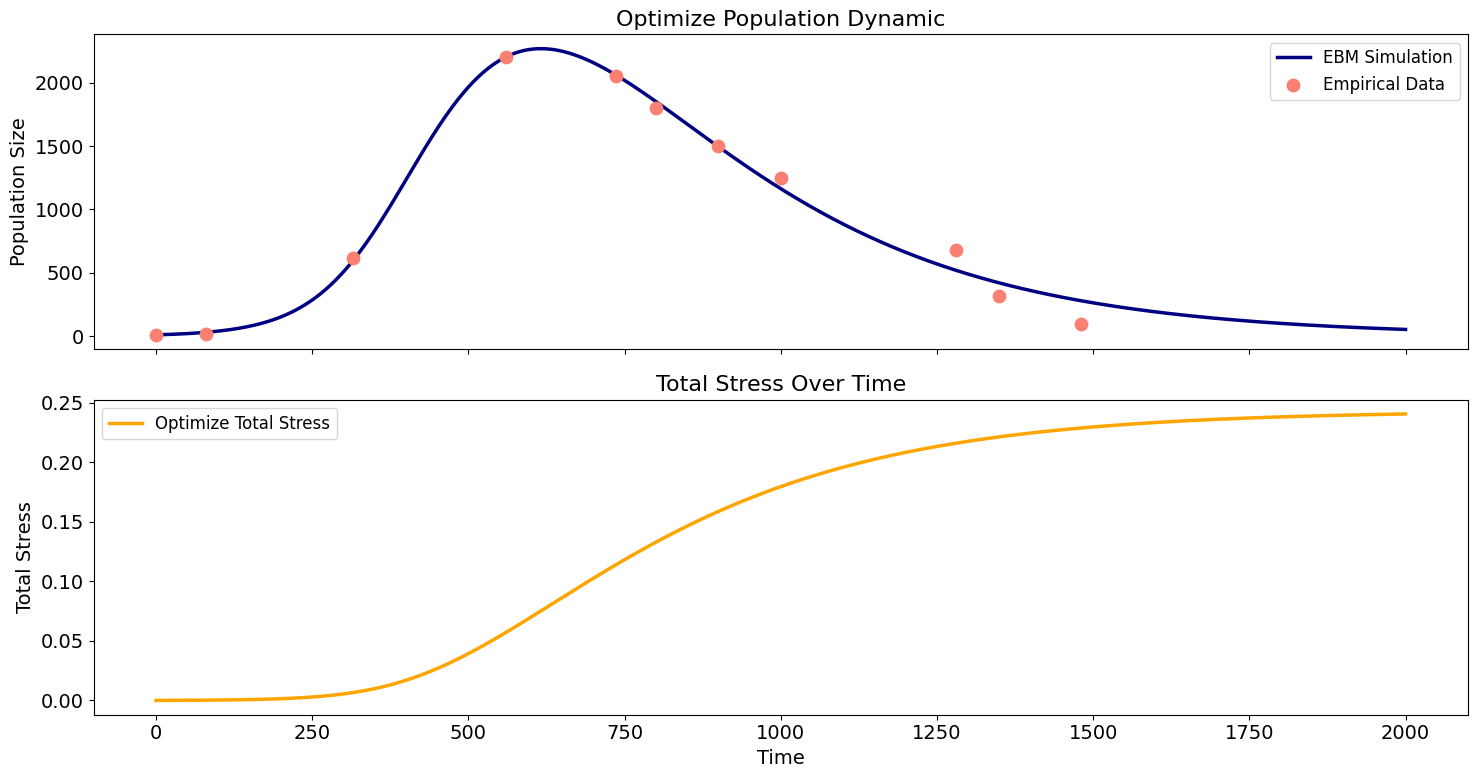

In [5]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_EBM, label="EBM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_EBM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

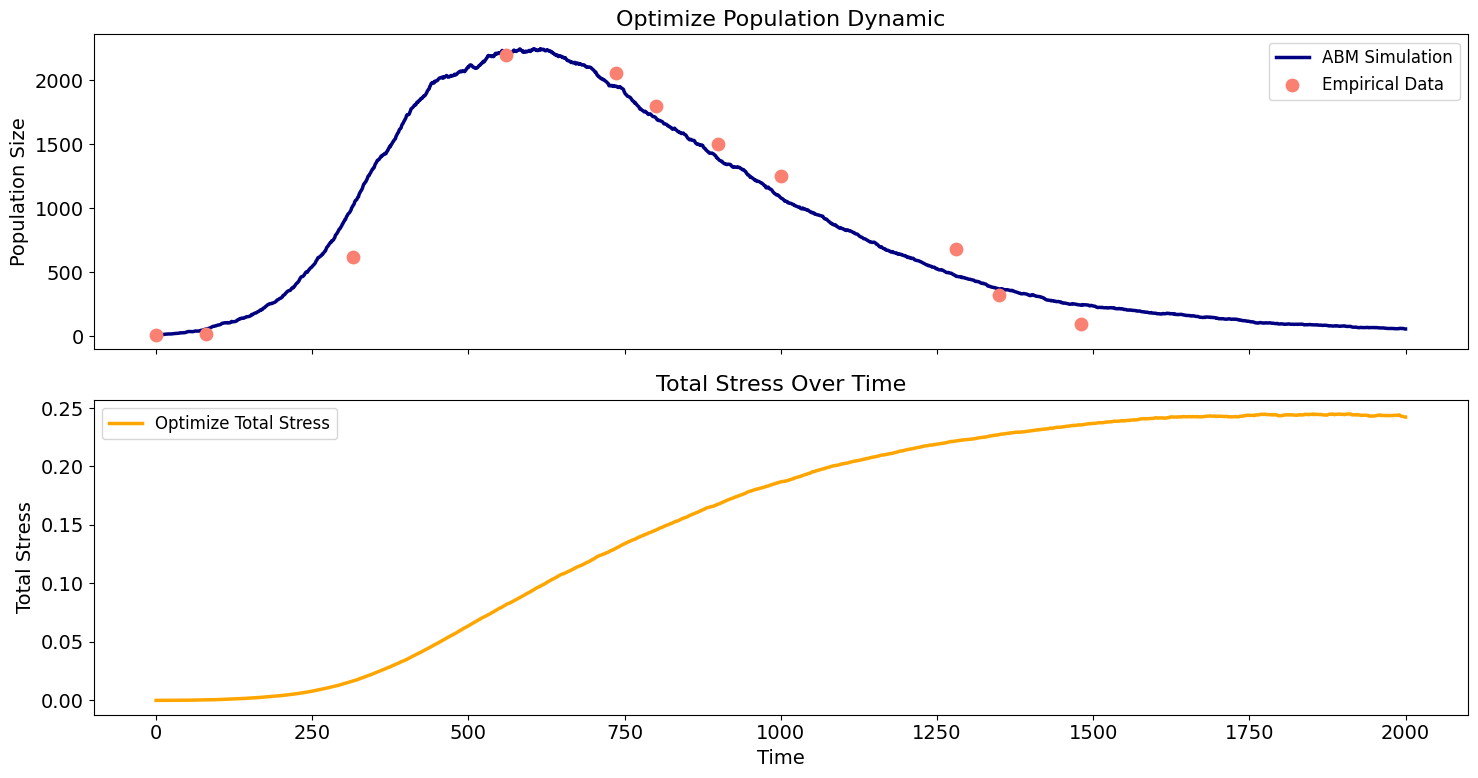

In [6]:
FIGSIZE = (15, 8)
LINEWIDTH = 2.5
MARKER_SIZE = 80
FONT_SIZE = 14

COLOR_EBM = "navy"
COLOR_ED = "salmon"
COLOR_STRESS = "orange"

TITLE_SIZE = 16
LABEL_SIZE = 14
LEGEND_SIZE = 12

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE
})

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)

ax = axes[0]
ax.plot(P_ts_ABM, label="ABM Simulation", color=COLOR_EBM, linewidth=LINEWIDTH)
ax.scatter(t_ED, p_ED, label="Empirical Data", color=COLOR_ED, s=MARKER_SIZE, zorder=3)
ax.set_ylabel("Population Size")
ax.set_title("Optimize Population Dynamic")
ax.legend()

ax = axes[1]
ax.plot(S_ts_ABM, label="Optimize Total Stress", color=COLOR_STRESS, linewidth=LINEWIDTH)
ax.set_ylabel("Total Stress")
ax.set_xlabel("Time")
ax.set_title("Total Stress Over Time")
ax.legend()

plt.tight_layout()
plt.show()

In [7]:
NUM_SIM = sims_u25.shape[0]

t_u25 = np.arange(sims_u25.shape[1], dtype=float)
idx_u25 = np.arange(NUM_SIM)

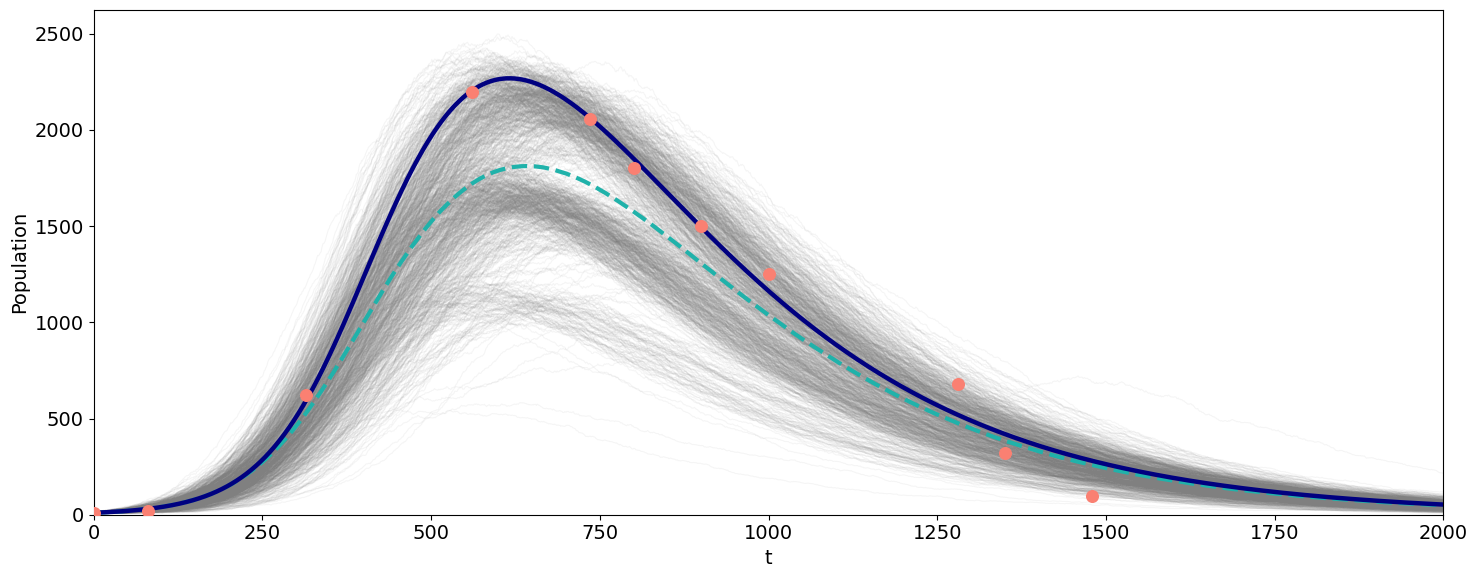

In [8]:
mean_u25 = np.nanmean(sims_u25, axis=0)
t_u25 = np.arange(sims_u25.shape[1], dtype=float)

fig, ax = plt.subplots(figsize=(15, 6))

for i in range(sims_u25.shape[0]):
    ax.plot(t_u25, sims_u25[i], color="grey", linewidth=0.8, alpha=0.08)

ax.plot(t_u25, mean_u25, color="lightseagreen", linewidth=3.0, linestyle="--")

S_ebm_u25, P_ebm_u25 = aggregate_model(T, c, m, n, d, k, R, P_0, s_0)
P_ebm_u25 = np.asarray(P_ebm_u25, dtype=float)
t_ebm_u25 = np.arange(len(P_ebm_u25), dtype=float)

ax.plot(t_ebm_u25, P_ebm_u25, color="navy", linewidth=3.2)
ax.scatter(t_ED, p_ED, color="salmon", s=70, zorder=5)

ax.set_xlabel("t")
ax.set_ylabel("Population")
ax.set_ylim(bottom=0)
ax.set_xlim(0, max(t_u25.max(), t_ebm_u25.max()))

plt.tight_layout()
plt.show()